# Lab 1: Data Analysis with Pandas and Sensor Data

## Setup

Let's start by importing necessary libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Next, we define an array of objects to easily access our data paths:

In [2]:
classes = [
    {
        'classname': 'laying_down',
        'recordings': [
            {
                'acc': '../data/laying_down_1/Accelerometer.csv',
                'gyro': '../data/laying_down_1/Gyroscope.csv'
            },
            {
                'acc': '../data/laying_down_2/Accelerometer.csv',
                'gyro': '../data/laying_down_2/Gyroscope.csv'
            },
            {
                'acc': '../data/laying_down_3/Accelerometer.csv',
                'gyro': '../data/laying_down_3/Gyroscope.csv'
            },
        ]
    },
    {
        'classname': 'standing_up',
        'recordings': [
            {
                'acc': '../data/standing_up_1/Accelerometer.csv',
                'gyro': '../data/standing_up_1/Gyroscope.csv'
            },
            {
                'acc': '../data/standing_up_2/Accelerometer.csv',
                'gyro': '../data/standing_up_2/Gyroscope.csv'
            },
            {
                'acc': '../data/standing_up_3/Accelerometer.csv',
                'gyro': '../data/standing_up_3/Gyroscope.csv'
            },
        ]
    },
    {
        'classname': 'circle',
        'recordings': [
            {
                'acc': '../data/circle_1/Accelerometer.csv',
                'gyro': '../data/circle_1/Gyroscope.csv'
            },
            {
                'acc': '../data/circle_2/Accelerometer.csv',
                'gyro': '../data/circle_2/Gyroscope.csv'
            },
            {
                'acc': '../data/circle_3/Accelerometer.csv',
                'gyro': '../data/circle_3/Gyroscope.csv'
            },
        ]
    }
]

## 1. Data Analysis: Plotting our data

Let's define a function plot_data which takes a classname, a path of a csv file and an array of column names and plots the data using a pandas dataframe.

In [3]:
def plot_data(classname, path, columns):
    dataset = (
        pd.read_csv(path,
                    usecols=[1,2,3],
                    names=columns,
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    )

    dataset.plot(title=f"{classname} Plot")
    plt.show()

### Plotting Accelerometer data

We load each accelerometer file and plot all components (X, Y, Z).

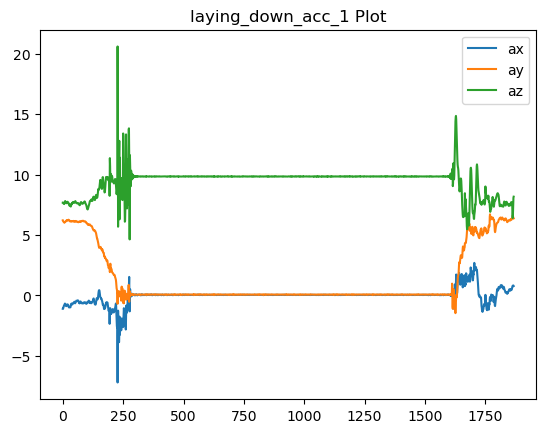

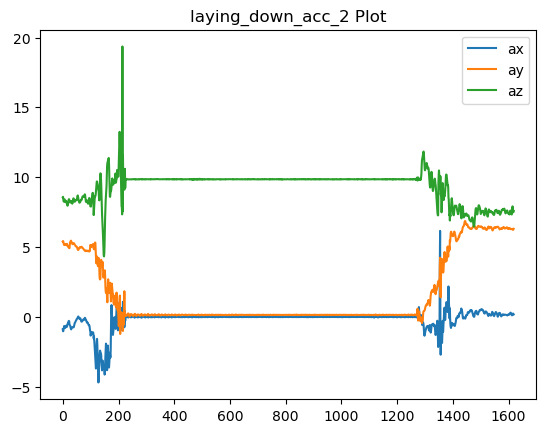

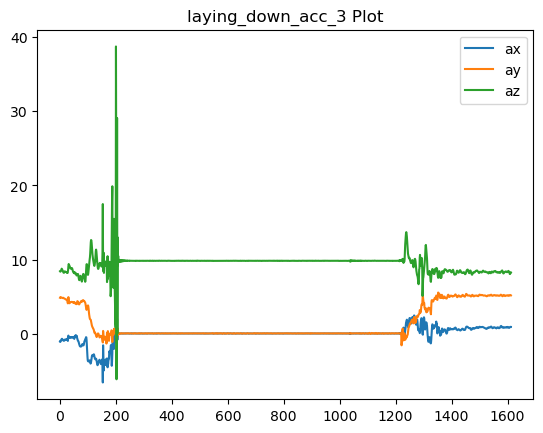

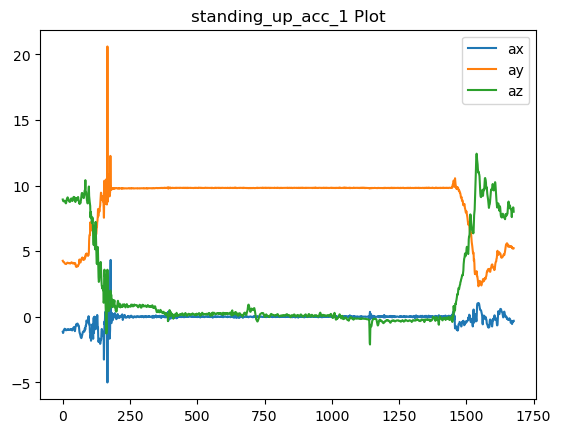

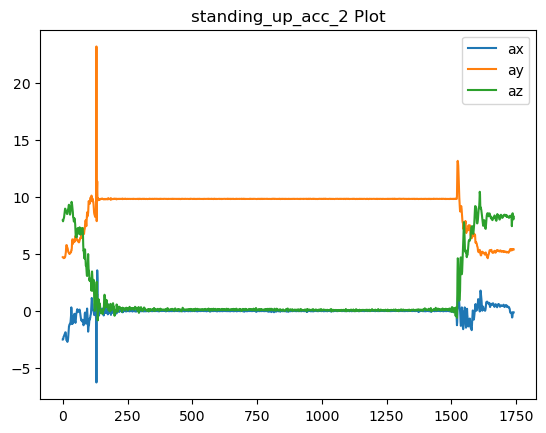

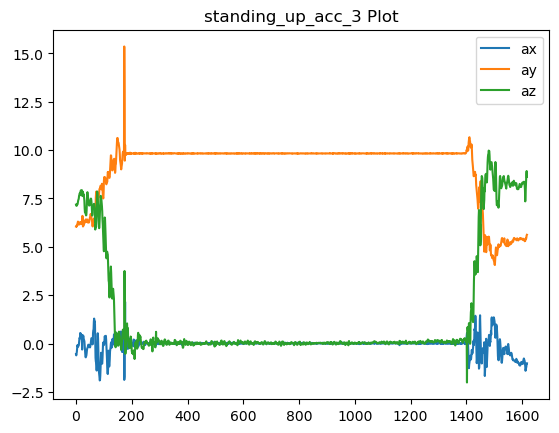

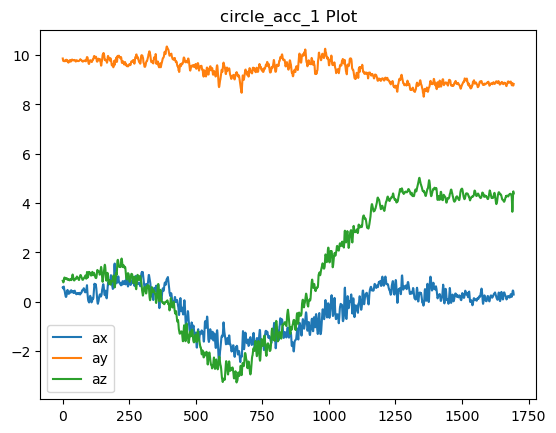

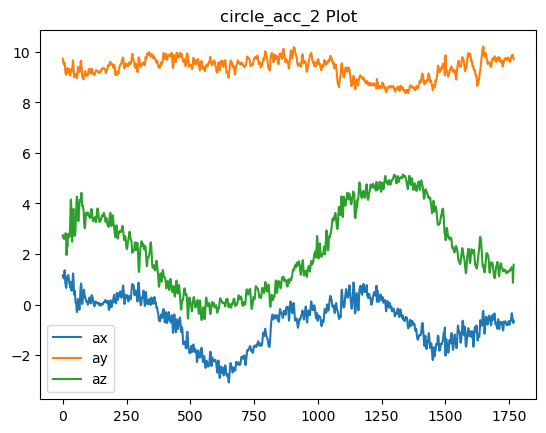

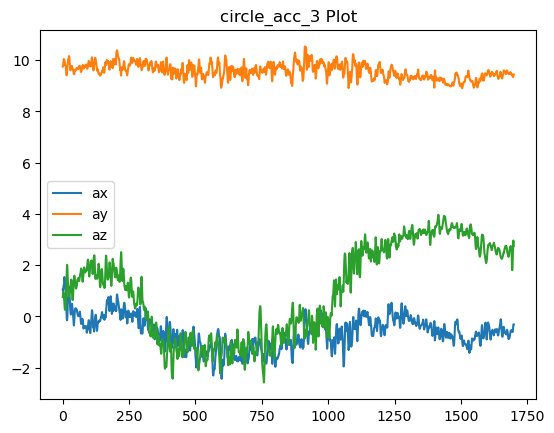

In [4]:
for cls in classes:
    classname = cls['classname']
    for i, recording in enumerate(cls['recordings'], 1):
        acc_path = recording['acc']
        plot_data(f"{classname}_acc_{i}", acc_path, ['ax', 'ay', 'az'])

#### Question: What are we measuring with the accelerometer?
We are measuring acceleration in the X, Y, and Z axes in m/s².

#### Question: Can we see differences between the three classes?
Yes. Both when the phone is laying down and standing up, the position on all axes is constant (roughly). But when the phone is moving in circles, the y axes looks roughly constant (within some error margin), and the x and z axes are represented by curves roughly trigonometric.

### Plotting Gyroscope data

We load each gyroscope file and plot all components (X, Y, Z).

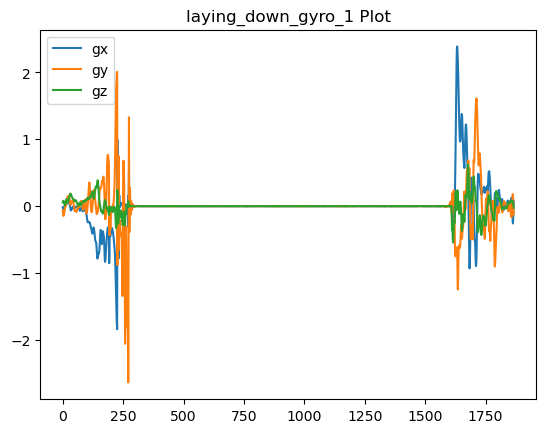

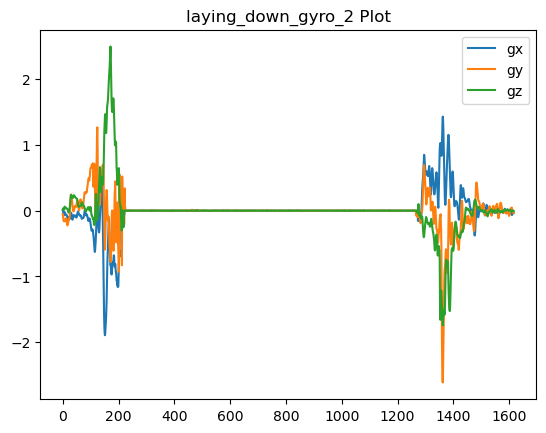

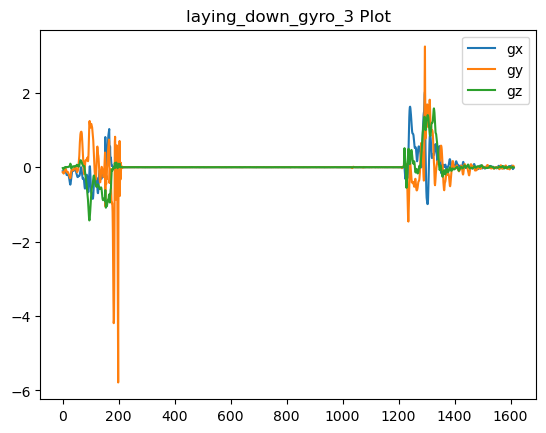

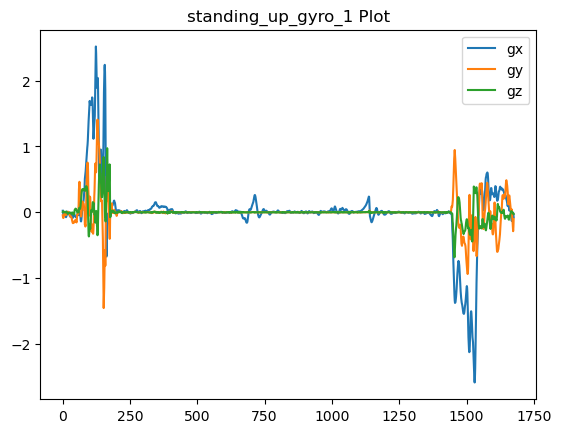

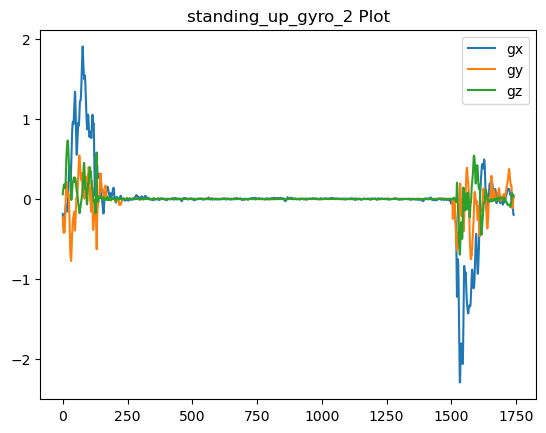

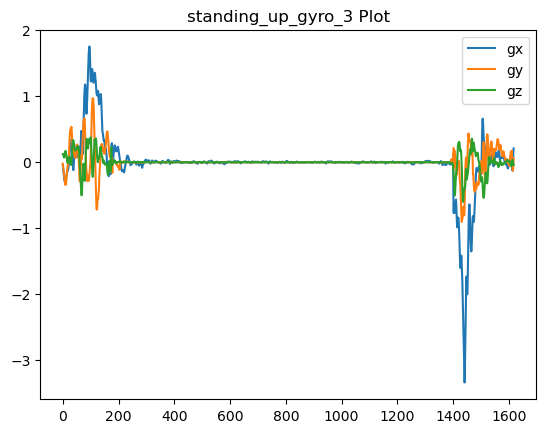

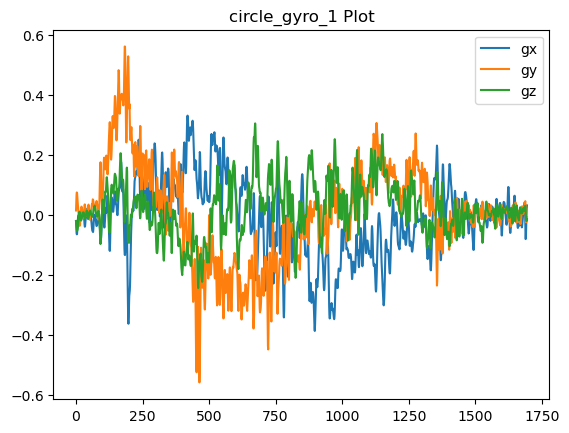

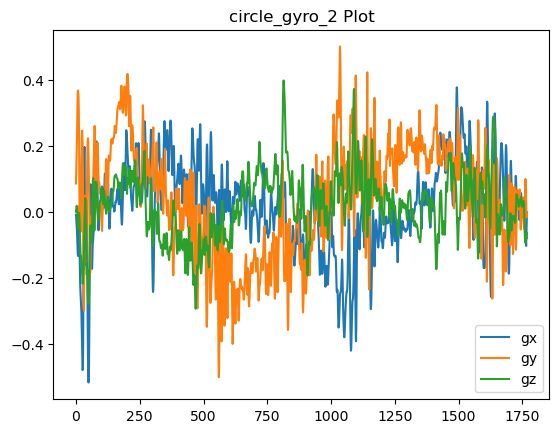

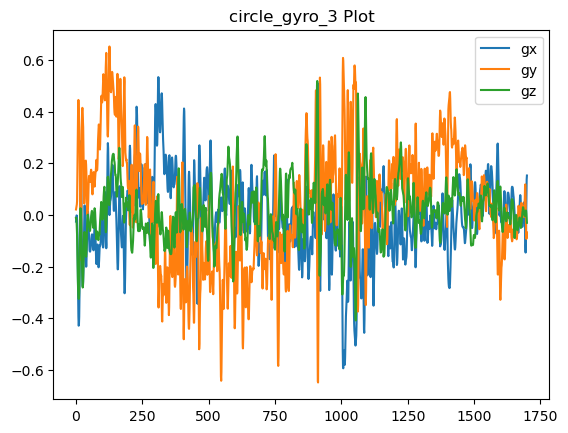

In [5]:
for cls in classes:
    classname = cls['classname']
    for i, recording in enumerate(cls['recordings'], 1):
        gyro_path = recording['gyro']
        plot_data(f"{classname}_gyro_{i}", gyro_path, ['gx', 'gy', 'gz'])

#### Question: What are we measuring with the gyroscope?
We are measuring the angular velocity in the X, Y, and Z axes. In other words, how quickly something is rotating or turning around an axis. 

#### Question: Can we see differences between the three classes?
Yes. Both when the phone is laying down and standing up, the position on all axes is constant (roughly). But when the phone is moving in circles, all axes are represented by curves roughly trigonometric.

## 2. Handling the data

### Create a python function that can read one accelerometer file and one rategyro file.

In [6]:
def read_acc_and_gyro(path_acc, path_gyro):
    dataset_acc = (
        pd.read_csv(path_acc,
                    usecols=[1,2,3],
                    names=['ax', 'ay', 'az'],
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    )
    print('\nAccelerometer')
    print(dataset_acc.head())
    
    dataset_gyro = (
        pd.read_csv(path_gyro,
                    usecols=[1,2,3],
                    names=['gx', 'gy', 'gz'],
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    )
    print('\nGyroscope')
    print(dataset_gyro.head())

    return (dataset_acc, dataset_gyro)

#### Question: What do you need as input to the function?

We need the following parameters:
- path_acc : str -> Path to accelerometer CSV (X, Y, Z in cols 1–3).
- path_gyro : str -> Path to gyroscope CSV (X, Y, Z in cols 1–3).

### Store each dataframe, one for each recording, in a binary file using the to_pickle function.

In this code block we're also defining whether the pickle file should go to test or training folders

In [7]:
for cls in classes:
    classname = cls['classname']
    for i, recording in enumerate(cls['recordings'], 1):
        acc_path = recording['acc']
        gyro_path = recording['gyro']
        print(f'\n{classname} {i}')
        dataset_acc, dataset_gyro = read_acc_and_gyro(acc_path, gyro_path)
        folder = "test" if i==1 else "training"
        dataset = pd.concat([dataset_acc, dataset_gyro], axis=1)
        dataset.to_pickle(f"../pickles/{folder}/{classname}.pkl")
        print('\nPickled file:')
        print(dataset.head())


laying_down 1

Accelerometer
         ax        ay        az
0 -1.105152  6.215076  7.680079
1 -1.113684  6.167475  7.672146
2 -1.044827  6.125861  7.672744
3 -0.977168  6.106701  7.617659
4 -0.883163  6.083799  7.586075

Gyroscope
         gx        gy        gz
0 -0.018156 -0.062507  0.057476
1 -0.029759 -0.101505  0.072284
2 -0.044261 -0.130298  0.079508
3 -0.051703 -0.145972  0.079781
4 -0.052409 -0.137122  0.075051

Pickled file:
         ax        ay        az        gx        gy        gz
0 -1.105152  6.215076  7.680079 -0.018156 -0.062507  0.057476
1 -1.113684  6.167475  7.672146 -0.029759 -0.101505  0.072284
2 -1.044827  6.125861  7.672744 -0.044261 -0.130298  0.079508
3 -0.977168  6.106701  7.617659 -0.051703 -0.145972  0.079781
4 -0.883163  6.083799  7.586075 -0.052409 -0.137122  0.075051

laying_down 2

Accelerometer
         ax        ay        az
0 -0.904719  5.394183  8.556058
1 -1.044528  5.419630  8.588839
2 -1.018332  5.377717  8.419541
3 -0.889899  5.278773  8.25937

## 3. Python

Let's start by defining an array of objects to easily access our training data paths:

In [8]:
pickled_training_files = [
    {
    'classname' :  'laying_down',
    'paths' : ['../pickles/training/laying_down_2.pkl', '../pickles/training/laying_down_3.pkl']
    },
    {
    'classname' :  'standing_up',
    'paths' : ['../pickles/training/standing_up_2.pkl', '../pickles/training/standing_up_3.pkl']
    },
    {
    'classname' :  'circle',
    'paths' : ['../pickles/training/circle_2.pkl', '../pickles/training/circle_3.pkl']
    }
]

### Create a python function that can read all binary-files from one class. The function should return a dataframe x with all the data and also a column with information of which class the data belongs to.

This function loads multiple pickled DataFrames, adds class labels as a new column, concatenate them, and save as one pickle file.
Parameters:
- pickled_training_files: list of dictionaries, each with 'classname' (str) and 'paths' (list of pickle file paths).

In [9]:
def concat_files(pickled_training_files):
    dfs = []
    for item in pickled_training_files:
        for path in item['paths']:
            df = pd.read_pickle(path)
            df['class'] = item['classname']
            dfs.append(df)
    x = pd.concat(dfs, axis=0, ignore_index=True).dropna()
    x.to_pickle(f"../pickles/training/concat/concat.pkl")
    return x

Let's call the function we just defined:

In [10]:
concat_files(pickled_training_files)

,ax,ay,az,gx,gy,gz,class
0,-0.904719,5.394183,8.556058,0.004286,-0.052965,0.022873,laying_down
1,-1.044528,5.419630,8.588839,-0.013671,-0.085029,0.033206,laying_down
2,-1.018332,5.377717,8.419541,-0.044311,-0.125491,0.025156,laying_down
3,-0.889899,5.278773,8.259375,-0.066592,-0.155490,0.012829,laying_down
4,-0.757425,5.176984,8.240514,-0.072717,-0.160764,0.008019,laying_down
...,...,...,...,...,...,...,...
10056,-0.603096,9.381292,2.117347,-0.105530,0.000282,0.017311,circle
10057,-0.528551,9.351054,2.568359,-0.020872,-0.064696,0.016076,circle
10058,-0.407004,9.343869,2.866090,0.076261,-0.092542,0.004321,circle
10059,-0.310903,9.379795,2.963088,0.136923,-0.085798,-0.014044,circle
